In [12]:
#Importing required packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import re 
from textblob import TextBlob

In [3]:
#loading data
df=pd.read_csv("twitter_training.csv",header=None)
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
#Assigning Values to coloumns 
df.columns=['id','topic','sentiment','text']
df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [9]:
#Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [10]:
#Text cleaning Function 
def clean_text(text):
    text=str(text)
    text=text.lower()
    text=re.sub(r'http \s+','',text) #Remove Links 
    text=re.sub(r'@ \w+','',text)# Remove Mentions
    text=re.sub(r'# \w+','',text) #Remove hashtags
    text=re.sub(r'[^a-z A-Z]','',text) #Remove Special Charachters
    text=text.strip() 
    return text

In [11]:
#Apply Cleaning 
df['clean_text']=df['text'].apply(clean_text)

In [13]:
#Sentiment Prediction 
def get_sentiment(text):
    score=TextBlob(text).sentiment.polarity
    if score>0:
        return "Positive"
    elif score<0:
        return "Negative"
    else:
        return "Neautral"
    

In [17]:
#Save Predicted Sentiment Seperately
df['predicted_Sentiment']=df["clean_text"].apply(get_sentiment)

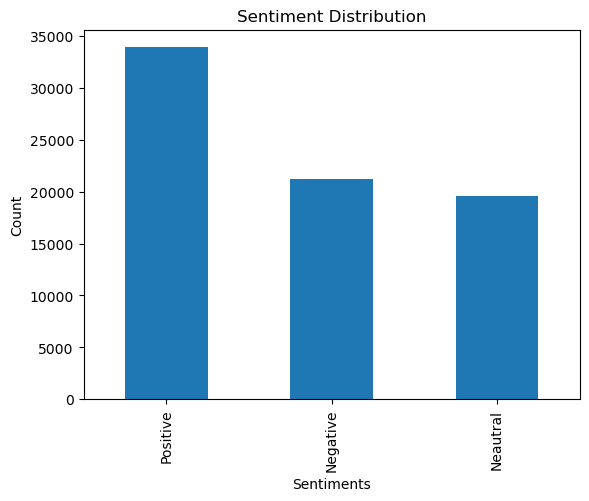

In [22]:
plt.Figure(figsize=(6,4))
df['predicted_Sentiment'].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Count")
plt.show()


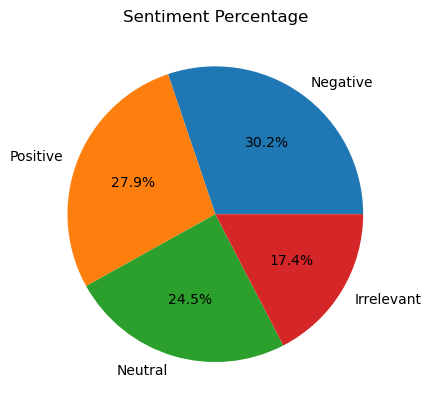

In [28]:
plt.Figure(figsize=(6,5))
df['sentiment'].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()

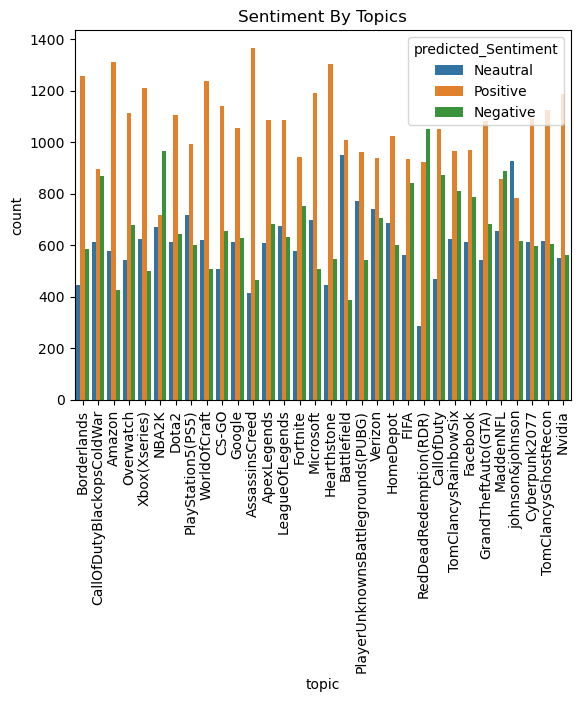

In [31]:
#Topic Wise Sentiment 
plt.Figure(figsize=(6,4))
sns.countplot(x="topic",hue="predicted_Sentiment",data=df)
plt.xticks(rotation=90)
plt.title("Sentiment By Topics")
plt.show()